Saving fashion_data_2018_2022.xls to fashion_data_2018_2022.xls
Dataset Loaded Successfully!
File: fashion_data_2018_2022.xls

================ FIRST 5 ROWS ================

   product_id    product_name  gender category     pattern  color age_group  \
0        1001    Biker Jacket    Male    Shirt   Geometric  White     25-35   
1        1002  Business Shirt    Male   Jacket  Polka Dots  Beige     18-24   
2        1003     Wool Jacket  Female    Dress   Geometric  Brown     18-24   
3        1004    Summer Dress    Male   Shorts       Plain  White     25-35   
4        1005    Casual Jeans    Male    Shirt       Plain  Beige     35-45   

   season   price   material  sales_count  reviews_count  average_rating  \
0  Spring   70.36  Synthetic           75             65             4.9   
1  Summer   91.59       Wool          296             25             3.5   
2     All  129.52       Wool           50             32             4.3   
3     All  116.01     Cotton          435     

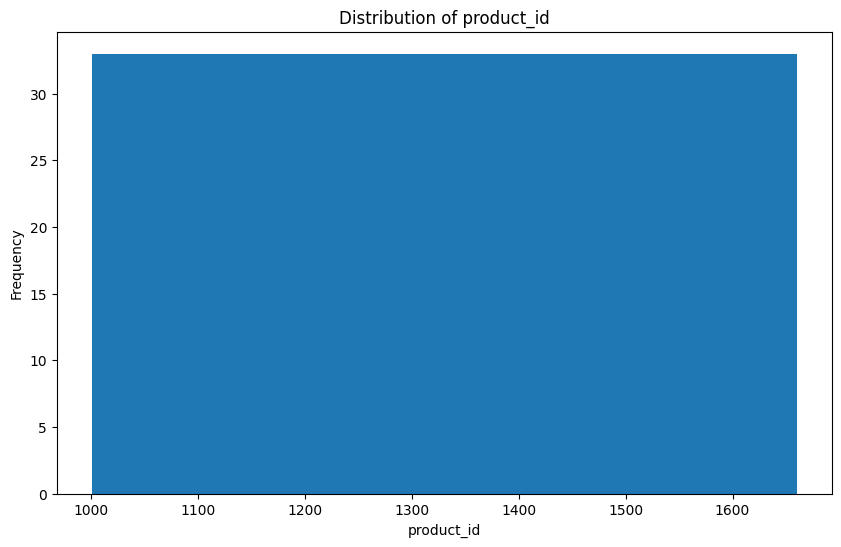

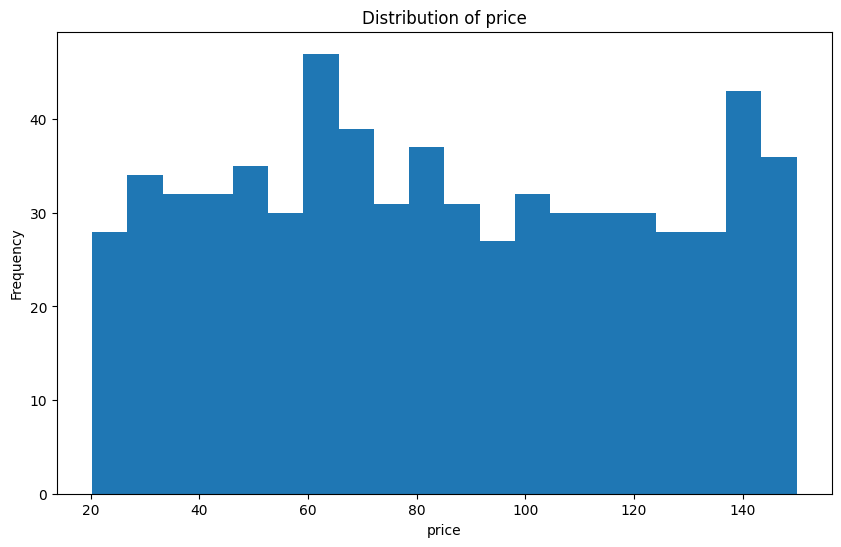

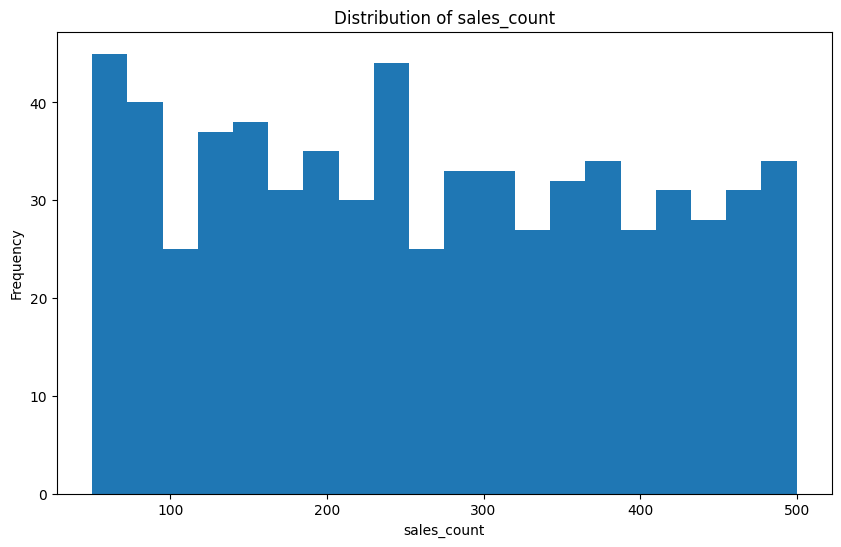

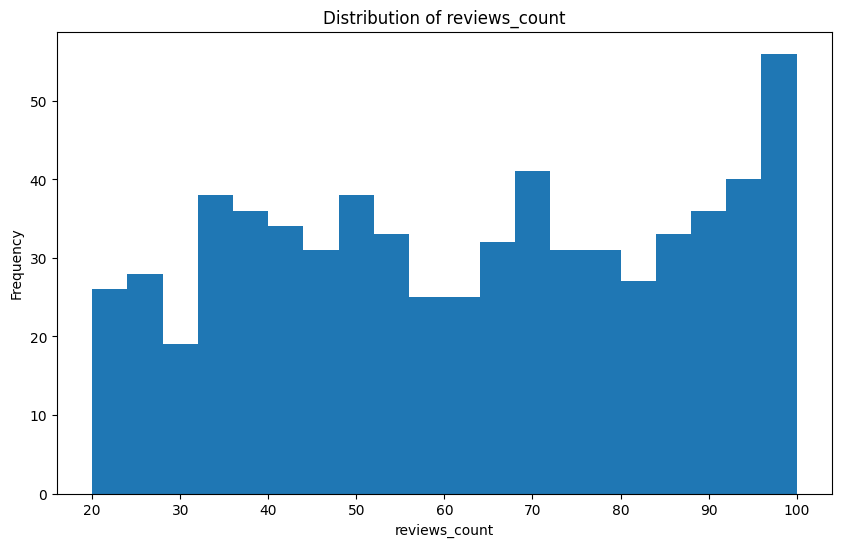

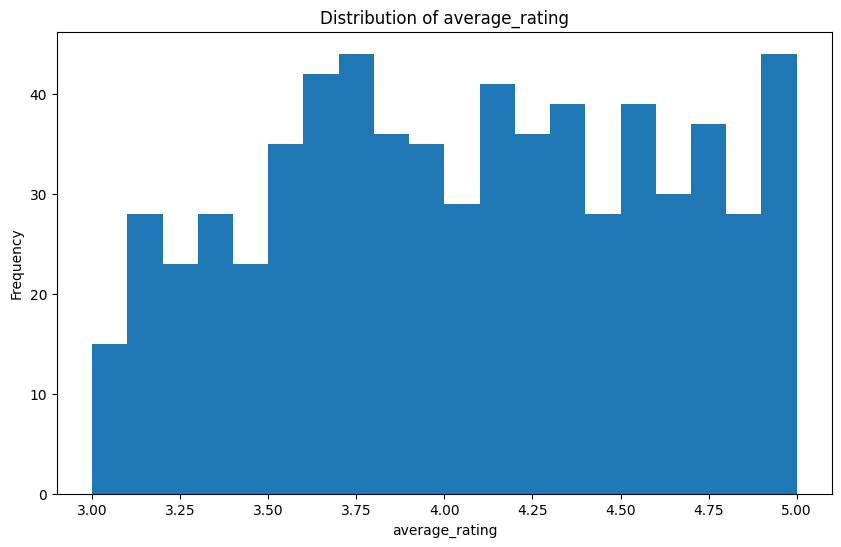

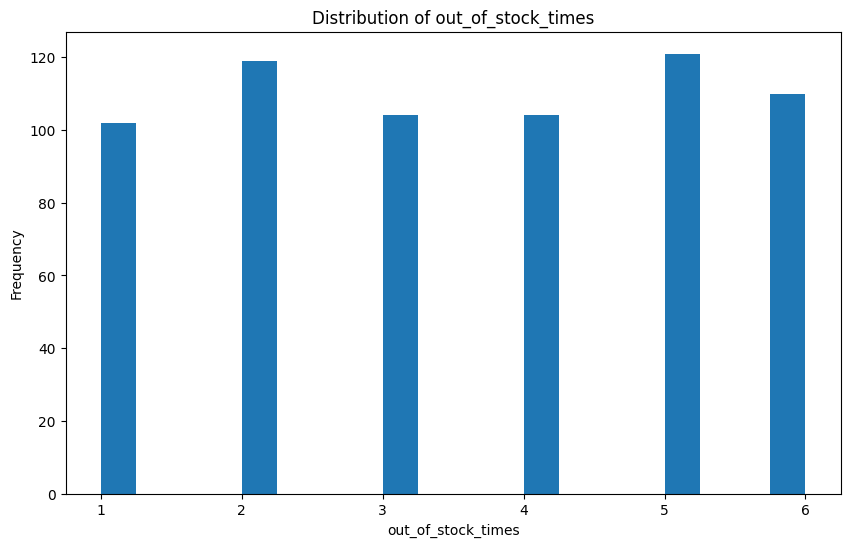

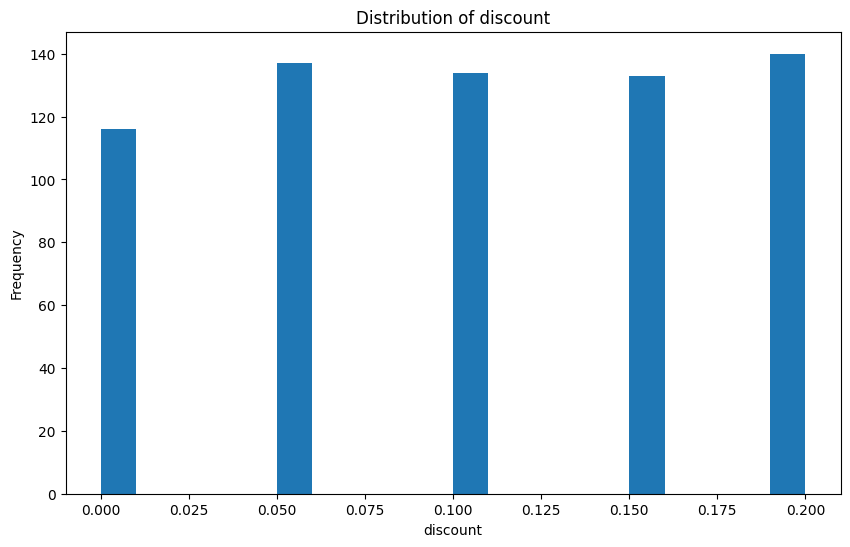

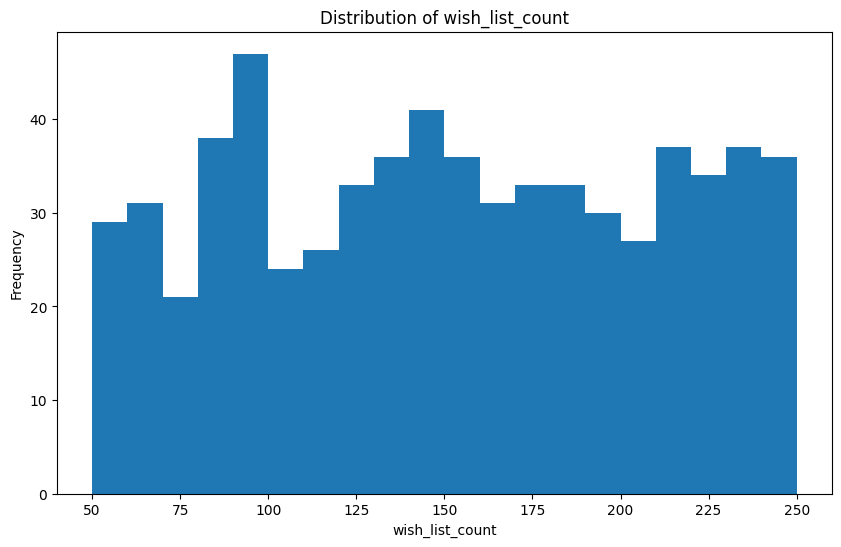

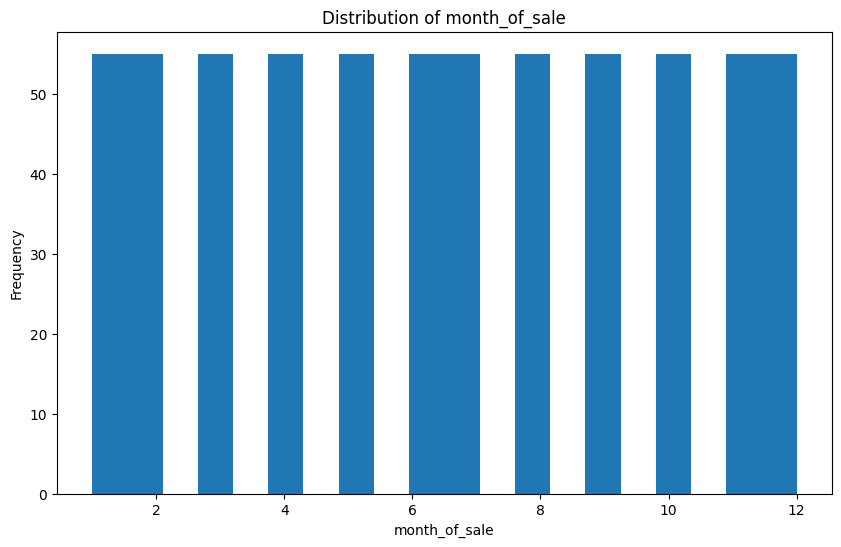

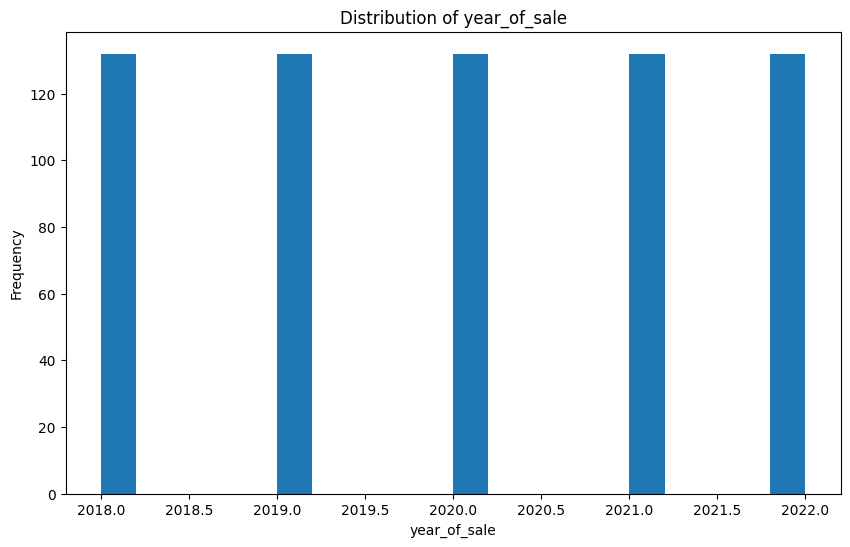

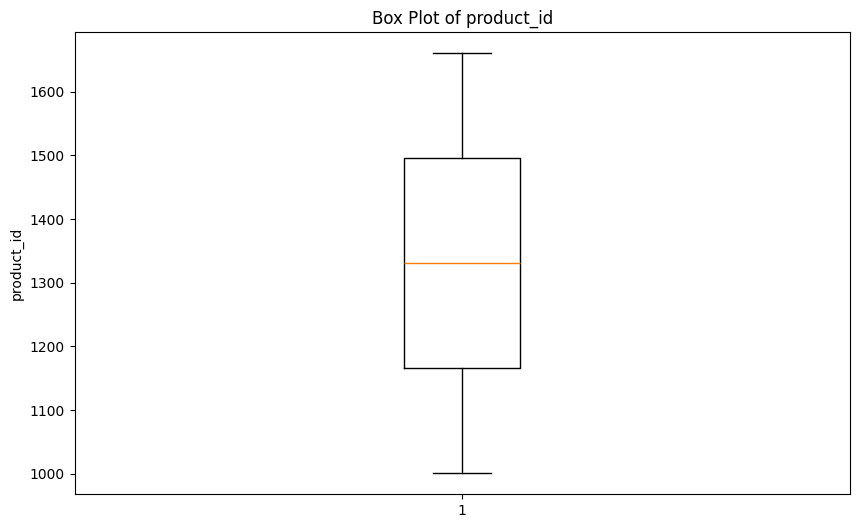

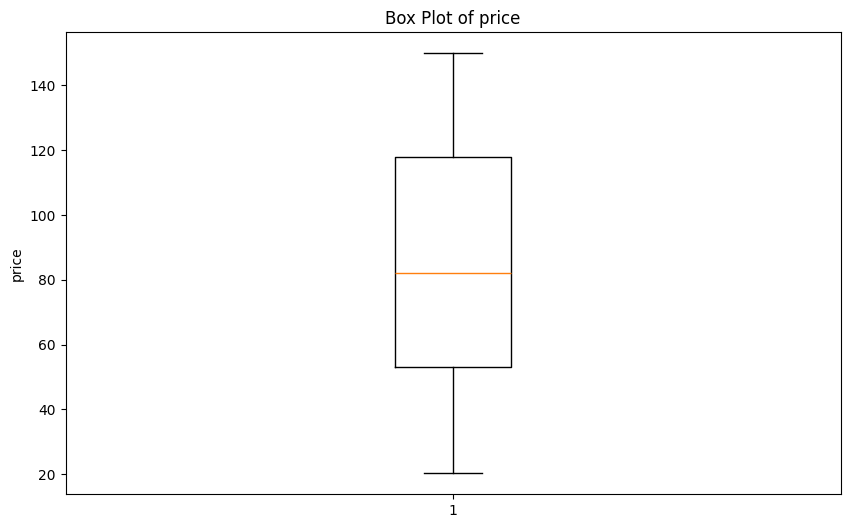

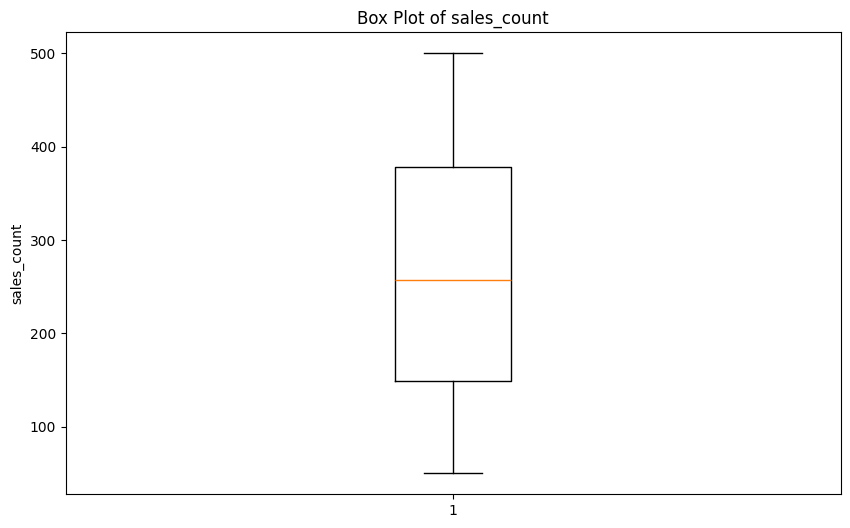

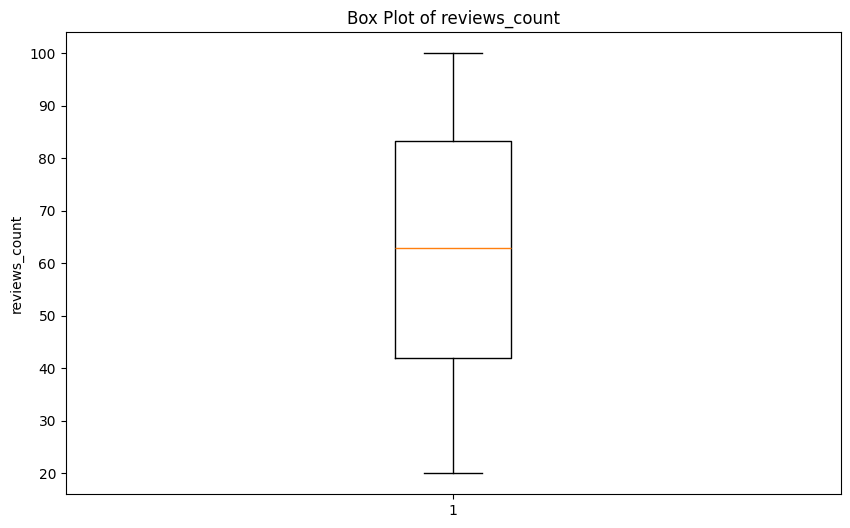

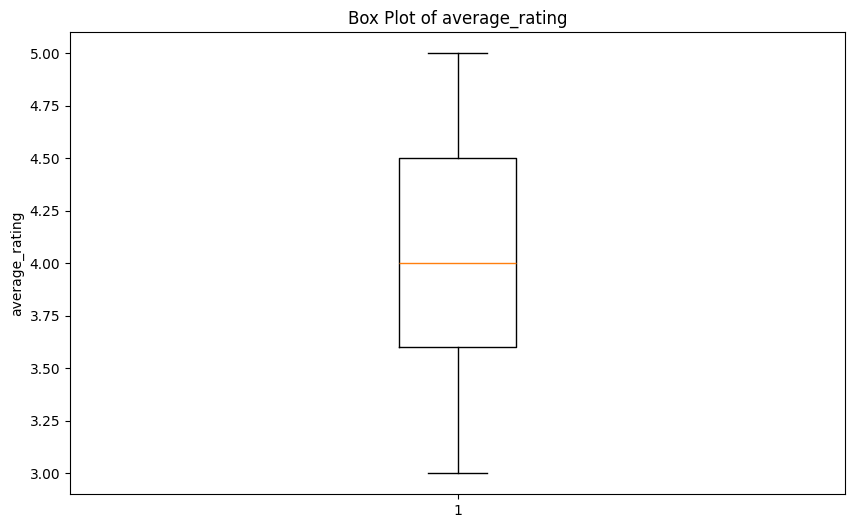

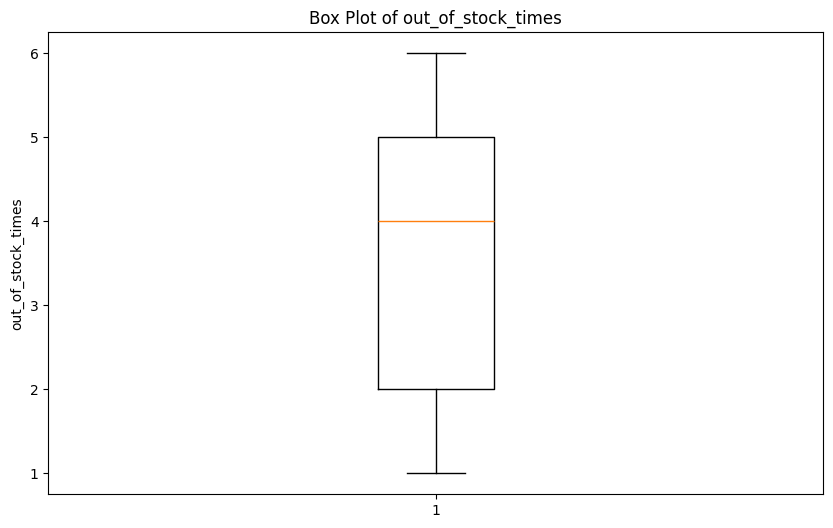

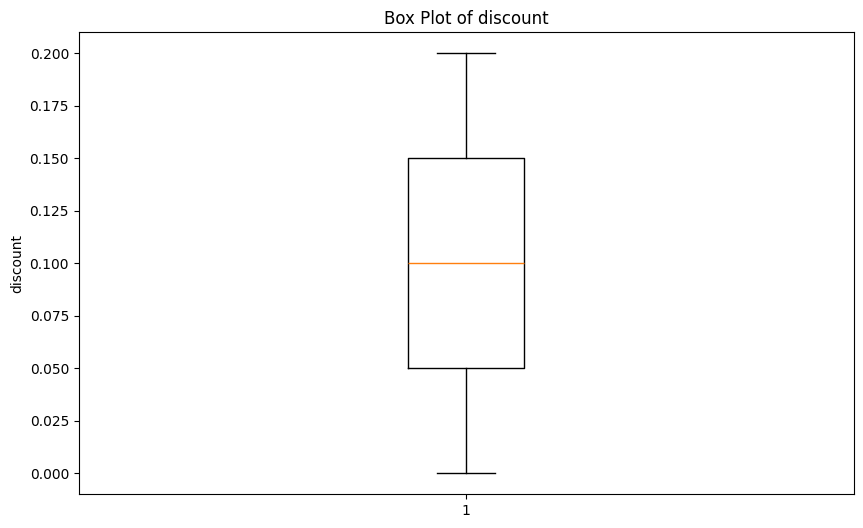

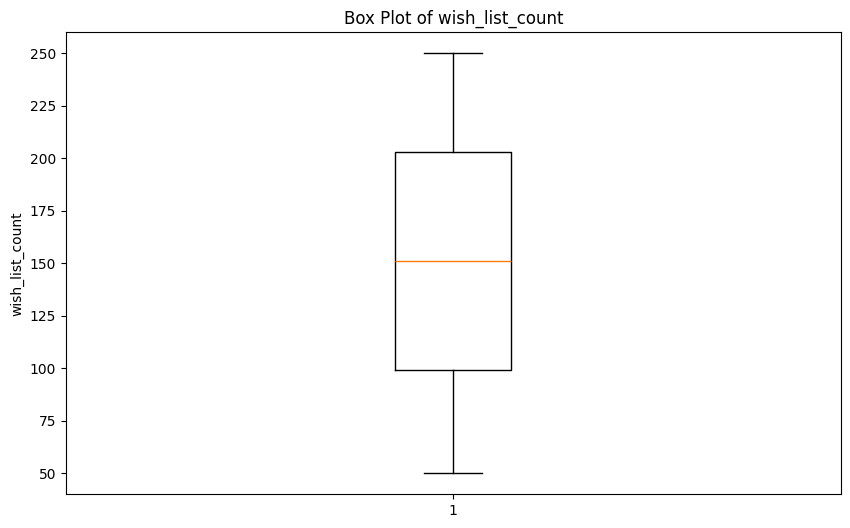

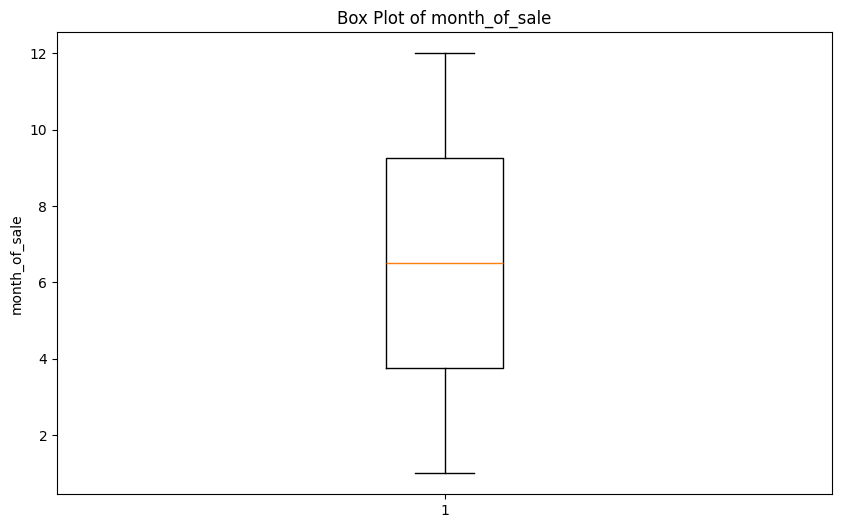

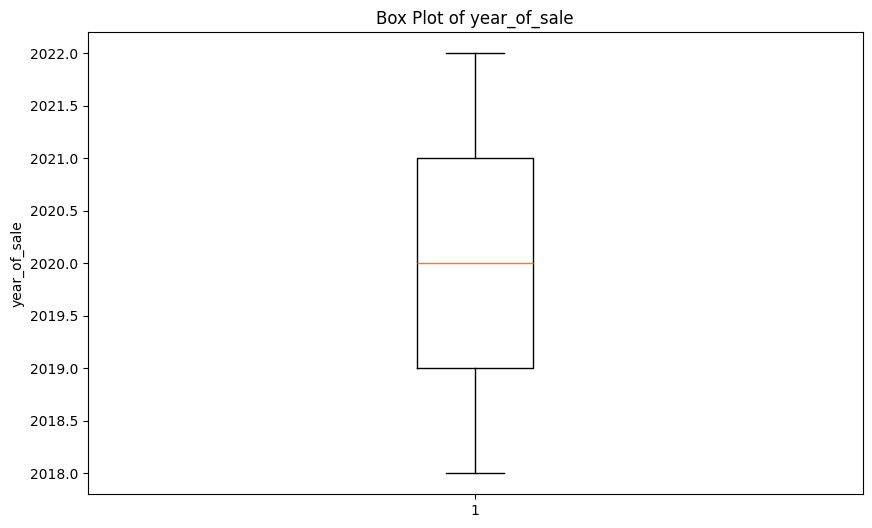

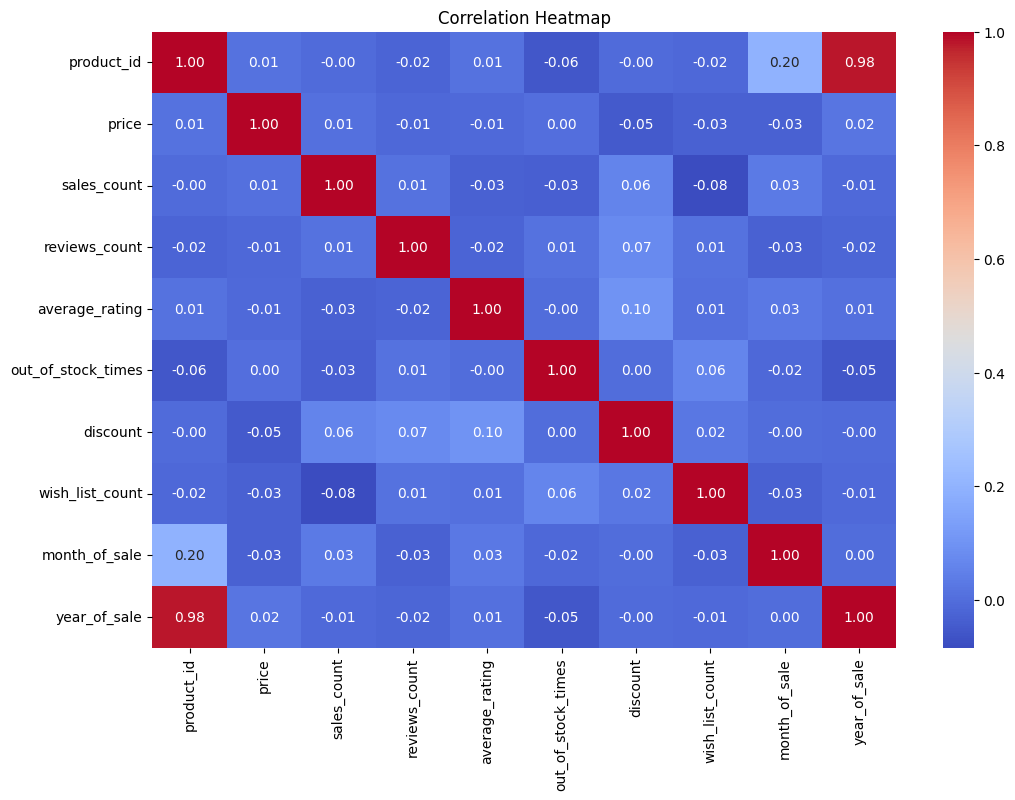

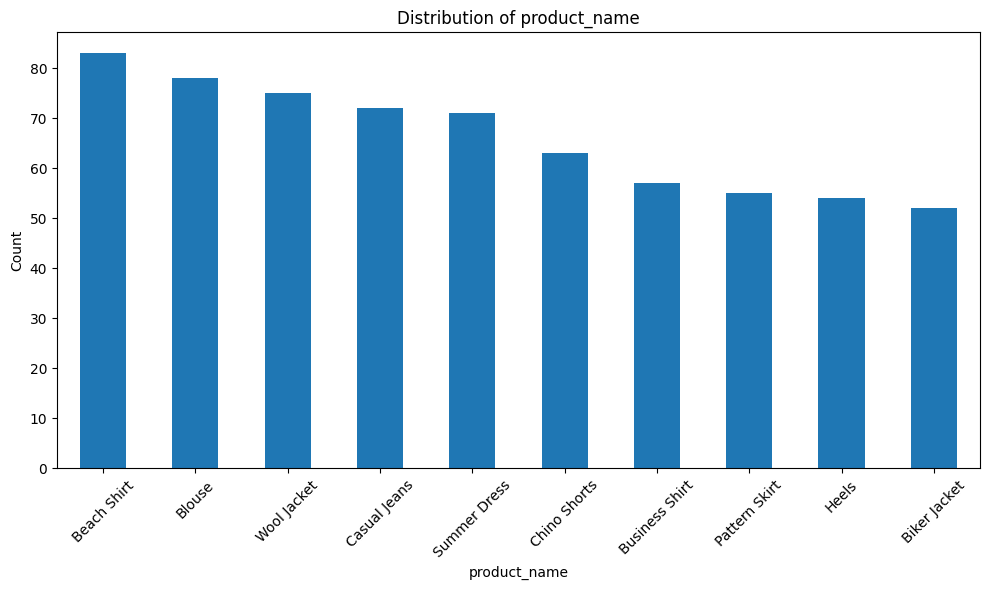

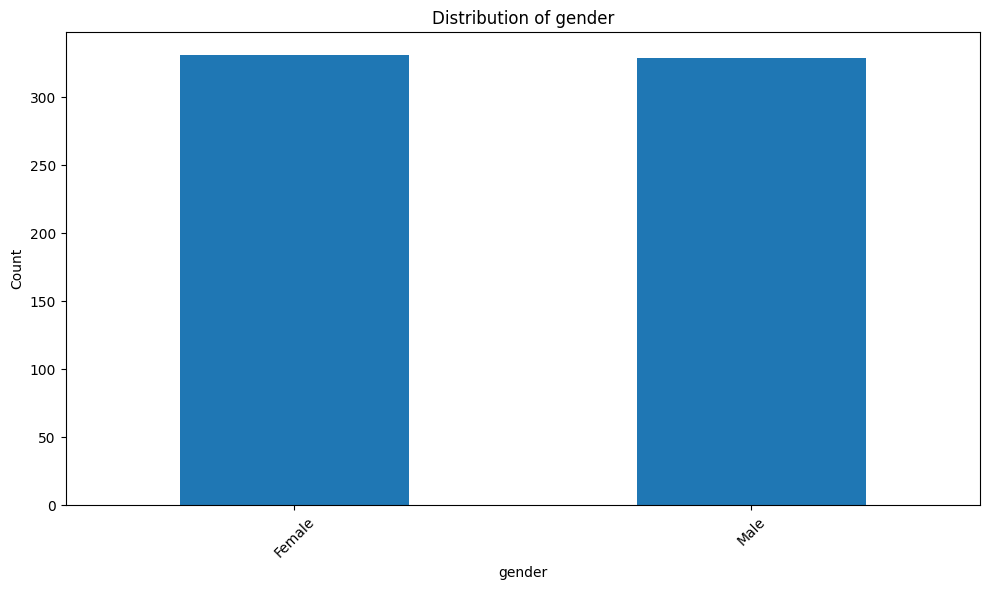

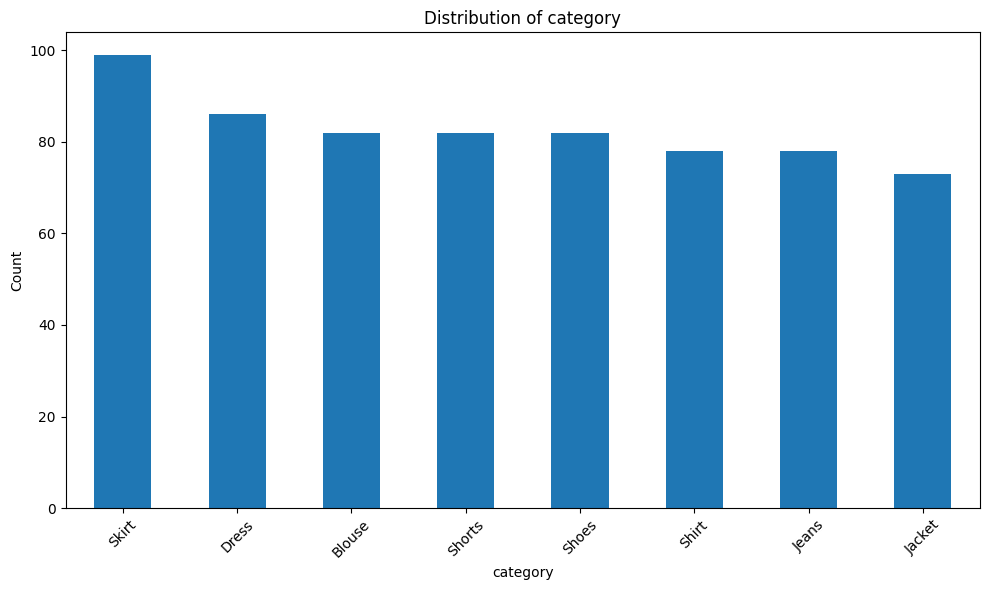

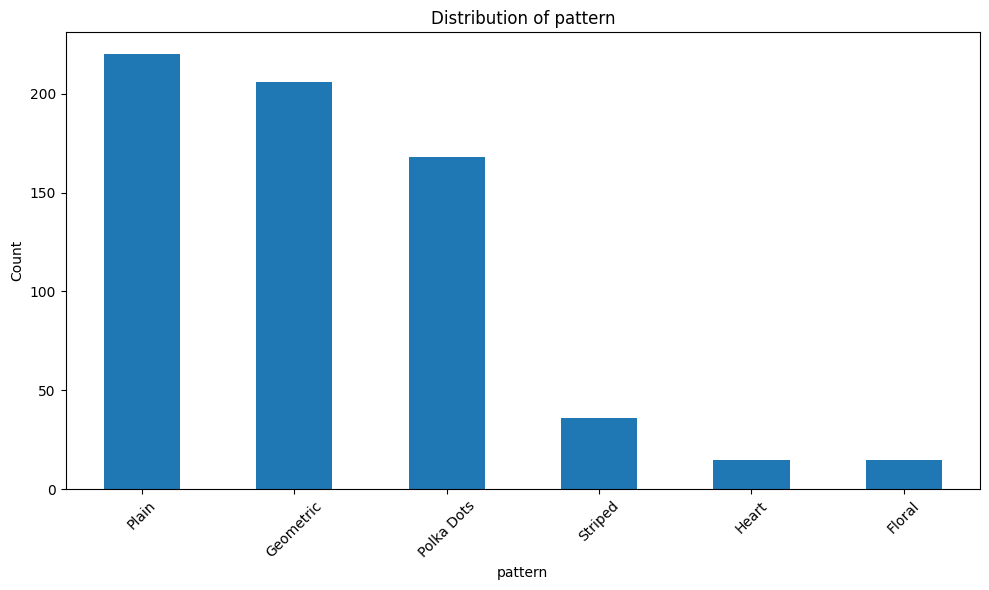

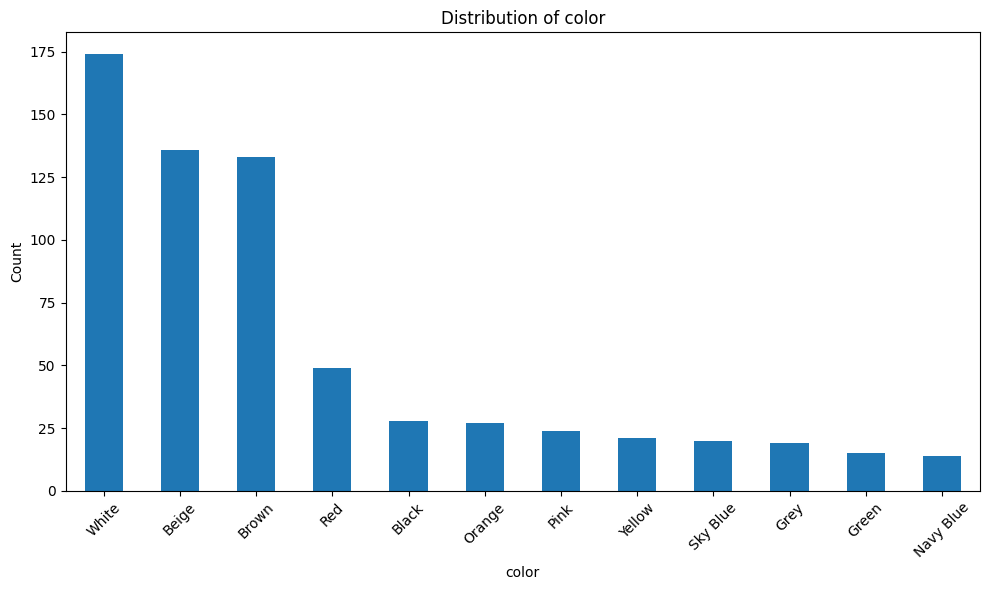

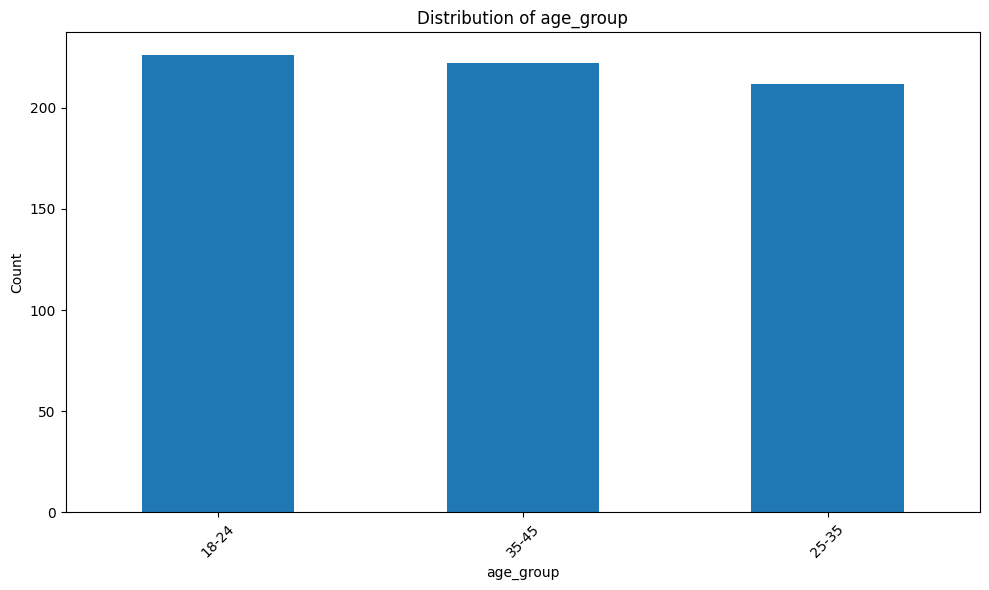

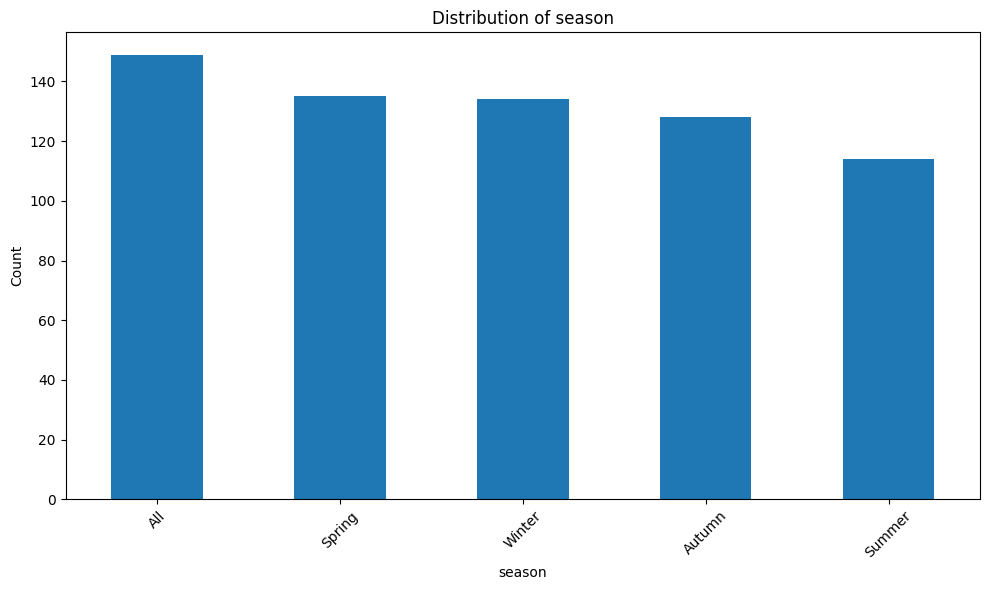

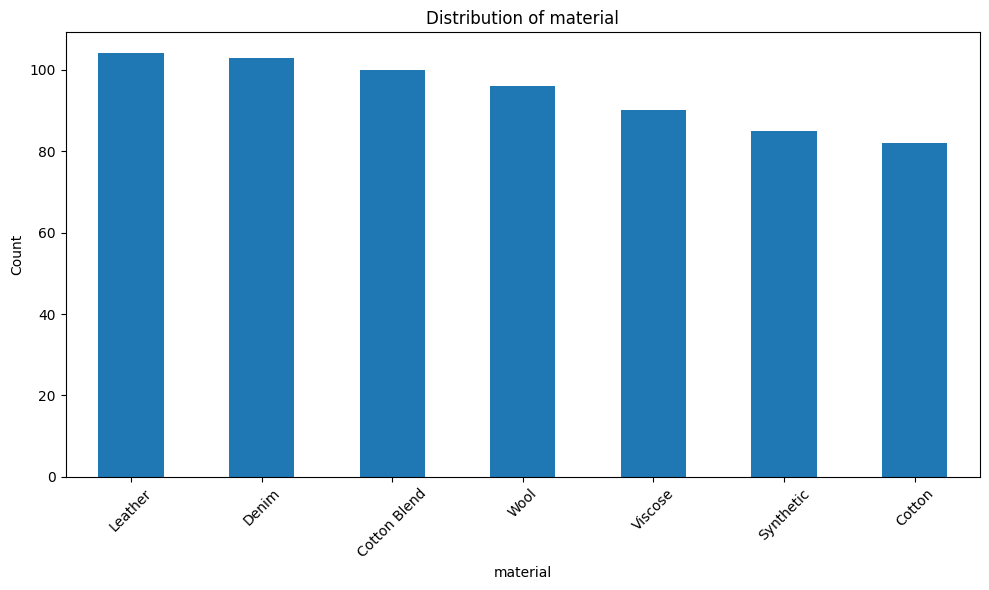

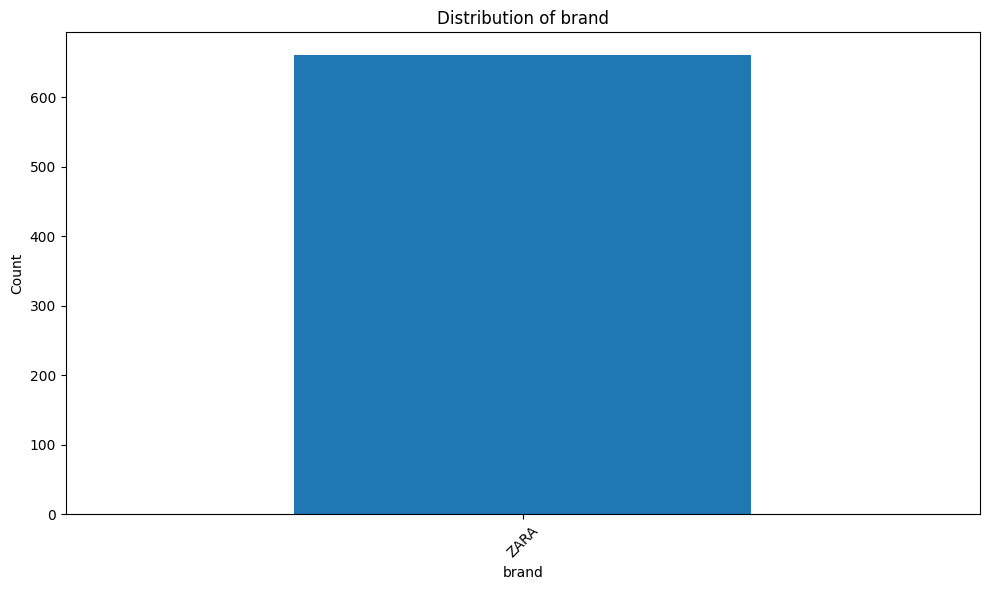


================ EXPERIMENT 1 SUMMARY ================

Dataset Name : fashion_data_2018_2022.xls
Number of Rows : 660
Number of Columns : 20
Duplicate Rows : 0
Total Missing Values : 0

Categorical Columns:
['product_name', 'gender', 'category', 'pattern', 'color', 'age_group', 'season', 'material', 'brand']

Numerical Columns:
['product_id', 'price', 'sales_count', 'reviews_count', 'average_rating', 'out_of_stock_times', 'discount', 'wish_list_count', 'month_of_sale', 'year_of_sale']


In [1]:
!pip install -q xlrd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

print("Dataset Loaded Successfully!")
print("File:", file_name)

print("\n================ FIRST 5 ROWS ================\n")
print(df.head())

print("\n================ LAST 5 ROWS ================\n")
print(df.tail())

print("\n================ DATASET SIZE ================\n")
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("\n================ DATA INFORMATION ================\n")
df.info()

print("\n================ DESCRIPTIVE STATISTICS ================\n")
print(df.describe())

categorical_columns = df.select_dtypes(include='object').columns

print("\n================ CATEGORICAL DATA ================\n")
for column in categorical_columns:
    print("\n", column)
    print("Unique :", df[column].nunique())
    print("Top :", df[column].mode()[0])
    print("Frequency :", df[column].value_counts().iloc[0])

print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())

print("\n================ MISSING VALUE PERCENTAGE ================\n")
print((df.isnull().sum() / len(df)) * 100)

print("\n================ DUPLICATE RECORDS ================\n")
print("Number of duplicate rows:", df.duplicated().sum())

print("\n================ UNIQUE VALUES ================\n")
print(df.nunique())

print("\n================ DATA TYPES ================\n")
print(df.dtypes)

print("\n================ CATEGORICAL DISTRIBUTIONS ================\n")
for column in categorical_columns:
    print("\n================", column.upper(), "================")
    print(df[column].value_counts())

numerical_columns = df.select_dtypes(include=np.number).columns

print("\n================ NUMERICAL DISTRIBUTIONS ================\n")
for column in numerical_columns:
    print("\n================", column.upper(), "================")
    print(df[column].describe())

for column in numerical_columns:
    plt.figure(figsize=(10,6))
    plt.hist(df[column].dropna(), bins=20)
    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

for column in numerical_columns:
    plt.figure(figsize=(10,6))
    plt.boxplot(df[column].dropna())
    plt.title("Box Plot of " + column)
    plt.ylabel(column)
    plt.show()

plt.figure(figsize=(12,8))
correlation = df[numerical_columns].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

for column in categorical_columns:
    if df[column].nunique() <= 20:
        plt.figure(figsize=(10,6))
        df[column].value_counts().plot(kind='bar')
        plt.title("Distribution of " + column)
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

print("\n================ EXPERIMENT 1 SUMMARY ================\n")
print("Dataset Name :", file_name)
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])
print("Duplicate Rows :", df.duplicated().sum())
print("Total Missing Values :", df.isnull().sum().sum())
print("\nCategorical Columns:")
print(list(categorical_columns))
print("\nNumerical Columns:")
print(list(numerical_columns))